In [19]:
import pandas as pd
import numpy as np

In [20]:
# Dataset
# Read in the data
df = pd.read_csv('../dataset/tweet_data/tweet_data.csv')

In [21]:
df.sample(10)

,textID,tweet_text,sentiment
48,1956989093,@RobertF3 correct! I ADORE him. I just plucked...,positive
16449,1753052720,@nicaliciousx hale yeahhh that's the coolest p...,positive
9625,1694014254,"@miasmom1 Awhhh age doesn't matter, you awesom...",positive
11363,1694791581,"@MissxMarisa haha what can i say, you're a gre...",positive
7934,1965441068,TwitterBerry hates me,negative
16390,1753029845,i think i just about have all my info syncing ...,positive
3865,1962000203,@cindaxo the straightener's another 110 pounds...,negative
5667,1963415485,"ouuuuuuuuuchhhhhhhh, still hurting from the Ba...",negative
4630,1962700257,@lyricals don't care about my struggles..,negative
6678,1964374843,@ladyinurdreamz dude!!! wtf!! I text you this ...,negative


## Visualise data

In [22]:
import matplotlib.pyplot as plt

           textID  tweet_text
sentiment                    
negative     8830        8830
positive     9897        9897


<BarContainer object of 2 artists>

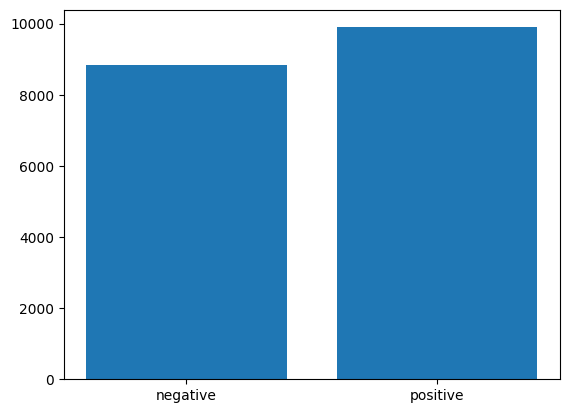

In [23]:
sentiment_count = df.groupby('sentiment').count()
# show number of count of positive and negative
print(sentiment_count)
# Showing the bar plot of positive and negative
plt.bar(sentiment_count.index.values, sentiment_count['tweet_text'])

# Using module to show most used words for pos and neg tweets

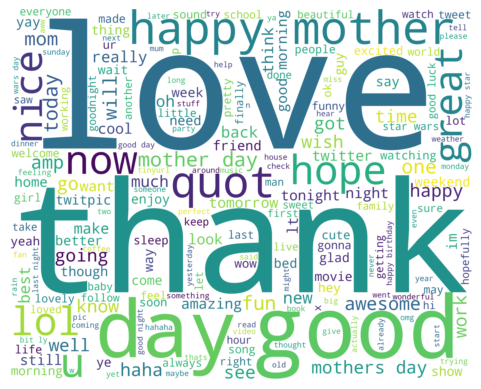

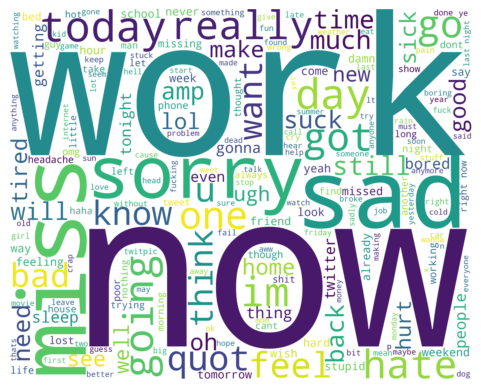

In [24]:
from wordcloud import WordCloud

positive_tweets = df[df['sentiment'] == 'positive']
negative_tweets = df[df['sentiment'] == 'negative']

txt_positive = " ".join(tweet.lower() for tweet in positive_tweets['tweet_text'])
txt_negative = " ".join(tweet.lower() for tweet in negative_tweets['tweet_text'])

# Generate a word cloud image
wordcloud_positive = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_positive)
wordcloud_negative = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_negative)

# Display the generated image:
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.show()

plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.show()



# Text Normalization

In [25]:
import re

In [26]:
example = "Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!!!!!"

In [27]:
# Remove emojis
import emoji

In [28]:

def convert_emoji_to_text(string):
    string = emoji.demojize(string) # Converting the emoji to their word meaning
    string = string.replace(":"," ") # Replacing the colon symbol with a space
    return string

print(convert_emoji_to_text(example))


Tom loved this fooooooood spot. This is their website for more info  https //www.examplefoodspot.com. I'm sure we'll go here again.  smiling_face_with_smiling_eyes  #food #greatfood #BESTFOOD!!!!!!


In [29]:
# Remove links
def remove_links(string, replace_with=""):
    string = re.sub('(http|https):\/\/\S+', replace_with, string) # regex to remove any links starting with http or https
    return string
print (remove_links(example))

Tom loved this fooooooood spot. This is their website for more info:  I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!!!!!


In [30]:
# Remove hashtags
def remove_hashtags(string, replace_with=""):
    string = re.sub('#+', replace_with, string) # regex to remove any hashtags
    return string

print (remove_hashtags(example))

Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 food greatfood BESTFOOD!!!!!!


In [31]:
# General cleaning / text normalization

In [32]:
# Making string all lowercase
def lower_case_string(string):
    return string.lower()

print (lower_case_string(example))

tom loved this fooooooood spot. this is their website for more info: https://www.examplefoodspot.com. i'm sure we'll go here again. 😊 #food #greatfood #bestfood!!!!!!


In [33]:
# Removing repeated characters
def remove_letter_repetitions(string):
    return re.sub(r'(.)\1+', r'\1\1', string) # regex to remove repeated chars, firstly matches a char which is repeated more than once, then replaces it with the same char twice

print (remove_letter_repetitions(example))

# Removing punctuation repetitions
def remove_punctuation_repetitions(string, replace_with=""):
    return re.sub(r'[\?\.\!]+(?=[\?\.\!])', replace_with, string) # regex to remove repeated punctuation, firstly matches a punctuation which is repeated more than once, then replaces it with a single punctuation

print (remove_punctuation_repetitions(example))

Tom loved this food spot. This is their website for more info: https://ww.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!
Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!


In [34]:
# Working with contractions
# Using a contraction dictionary we can replace contractions with their full form
import contractions

In [35]:
# Replacing contractions with their full form: e.g I'm -> I am
def replace_contractions(string):
    string = contractions.fix(string) # Using built in method from contractions library
    return string

print(replace_contractions(example))

Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I am sure we will go here again. 😊 #food #greatfood #BESTFOOD!!!!!!


# Tokenization
- stop words
- punctionation
- numbers

In [36]:
# Using nltk library
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [37]:
def tokenize(string):
    tokens = word_tokenize(string)
    return tokens

print(tokenize(example))

['Tom', 'loved', 'this', 'fooooooood', 'spot', '.', 'This', 'is', 'their', 'website', 'for', 'more', 'info', ':', 'https', ':', '//www.examplefoodspot.com', '.', 'I', "'m", 'sure', 'we', "'ll", 'go', 'here', 'again', '.', '😊', '#', 'food', '#', 'greatfood', '#', 'BESTFOOD', '!', '!', '!', '!', '!', '!']


In [38]:
# Using a more complex and complete tokenizer
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [39]:
stop_words = set(stopwords.words('english')) # Getting the stop words from nltk
print(stop_words)

{'while', 'should', 'was', "doesn't", "wasn't", 'but', "hasn't", 'haven', 'your', 's', 'so', 'wouldn', 'why', 'they', 'don', 'very', 'for', 'when', 'have', 'them', 're', 'been', 'until', 'below', 'i', 'a', 'further', 'an', 'more', "shan't", 'himself', 'its', 'hasn', 'me', "isn't", 've', 'here', 'hers', 'is', 'any', 'did', 'through', 'we', 'yourselves', "you've", 'nor', "don't", 'that', 'what', 'if', 'each', 'no', 'ain', 'under', 'hadn', 'ma', 'aren', 'out', "couldn't", 'my', 'didn', 'him', "should've", 'had', 'same', 'won', 'her', "hadn't", 'be', 'off', 'and', 'd', 'at', 'up', 'as', 'only', 'does', 'than', 'of', 'above', 'now', 'after', 'mustn', 'who', 'yours', 'you', 'where', 'itself', 'which', 'this', 'couldn', 'shan', 'to', 'not', 'herself', 'the', "haven't", 'it', 'o', "weren't", 'she', 'just', 'once', 'other', 'too', 'some', 'own', 'by', 'his', 'such', "wouldn't", "you'll", "mightn't", 'those', 'in', 'having', 'y', 'ourselves', 'isn', 'how', 'yourself', 'between', 'myself', 'are',

In [40]:
# Depending if we want to keep punctuation, alphanumeric characters and stopwords we can use the following function with True or False
def custom_tokenization(string, keep_punctuation = False, keep_alphanum = False, keep_stopwords = False):
    token_list = word_tokenize(string)

    if not keep_punctuation:
        token_list = [token for token in token_list if token not in string.punctuation] # Add only if not in the punctuation list
    if not keep_alphanum:
        token_list = [token for token in token_list if token.isalpha()] # Add only if is a letter
    if not keep_stopwords:
        stop_words = set(stopwords.words('english'))
        stop_words.discard('not', 'below', 'above') # Remove stop words which are relevant for sentiment analysis from the stop words list !NOTE: Can add more words to be excluded
        token_list = [token for token in token_list if token not in stop_words] # Add only if not in the stop words list

    return token_list

## Stemming

In [41]:
from nltk.stem import PorterStemmer 
from nltk.stem import LancasterStemmer # more agressive stemming
from nltk.stem import SnowballStemmer # better than porter and newer
#NOTE: can look at more stemming algos

In [42]:
porter_stemmer = PorterStemmer()
lancaster_stemmer = LancasterStemmer()
snowball_stemmer = SnowballStemmer('english')


In [43]:
# Function to stem tokens given a stemming algorithm
def stemming_tokens(tokens, stemmer):
    token_list = [stemmer.stem(token) for token in tokens] # Add the new stemmed token to the list
    return token_list

In [ ]:
print(stemming_tokens(tokenize(example), snowball_stemmer))